# 🌸 Module 5 – Data Science Mini Project
## Iris Flower Classification using Python and KNN

### Project Objective
This project analyzes the classic **Iris dataset** from the UCI Machine Learning Repository and builds a **K-Nearest Neighbors (KNN)** machine learning model to classify iris flowers into three species:

- Iris-setosa
- Iris-versicolor
- Iris-virginica

### Module 5 Requirements Covered
1. Real-world/public dataset
2. Data loading
3. Data cleaning
4. Exploratory Data Analysis (EDA)
5. 6 visualizations
6. Key insights
7. KNN machine learning model
8. Accuracy and evaluation
9. New-flower prediction
10. Conclusion

**Dataset source:** UCI Machine Learning Repository – Iris Dataset  
https://archive.ics.uci.edu/dataset/53/iris

In [1]:
# Step 1: Install and import required libraries
!pip -q install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_theme(style="whitegrid")

## 1. Dataset

The Iris dataset contains **150 observations**, **4 numerical features**, and a categorical target representing three iris species. The four measurements are sepal length, sepal width, petal length, and petal width. The UCI repository reports 50 observations for each of the three classes and no missing values. citeturn0search0

In [2]:
# Step 2: Load the public Iris dataset from UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"

columns = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
    "species"
]

df = pd.read_csv(url, header=None, names=columns)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
# Step 3: Basic EDA
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

print("\nStatistical summary:")
display(df.describe())

Dataset shape: (150, 5)

Column names:
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

Data types:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

First 5 rows:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa



Statistical summary:


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## 2. Data Cleaning

The UCI documentation states that the Iris dataset has no missing values. We still perform standard cleaning checks so the notebook demonstrates a complete data-science workflow.

In [4]:
# Step 4: Check missing values and duplicates
print("Missing values before cleaning:")
print(df.isnull().sum())

print("\nDuplicate rows before cleaning:", df.duplicated().sum())

Missing values before cleaning:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Duplicate rows before cleaning: 3


In [5]:
# Step 5: Clean the dataset
df = df.dropna().copy()
df = df.drop_duplicates().copy()

# Clean any accidental whitespace in the target column
df["species"] = df["species"].str.strip()

print("Shape after cleaning:", df.shape)
print("\nMissing values after cleaning:")
print(df.isnull().sum())

print("\nDuplicate rows after cleaning:", df.duplicated().sum())

Shape after cleaning: (147, 5)

Missing values after cleaning:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Duplicate rows after cleaning: 0


## 3. Exploratory Data Analysis (EDA)

We examine class distribution, averages, and relationships between flower measurements.

In [6]:
# Step 6: Species distribution
print(df["species"].value_counts())

print("\nAverage measurements by species:")
display(df.groupby("species").mean(numeric_only=True).round(2))

species
Iris-versicolor    50
Iris-virginica     49
Iris-setosa        48
Name: count, dtype: int64

Average measurements by species:


,sepal_length,sepal_width,petal_length,petal_width
species,,,,
Iris-setosa,5.01,3.43,1.46,0.25
Iris-versicolor,5.94,2.77,4.26,1.33
Iris-virginica,6.60,2.98,5.56,2.03


## 4. Visualizations

### Visualization 1 – Species Count
Shows how many flowers belong to each species.

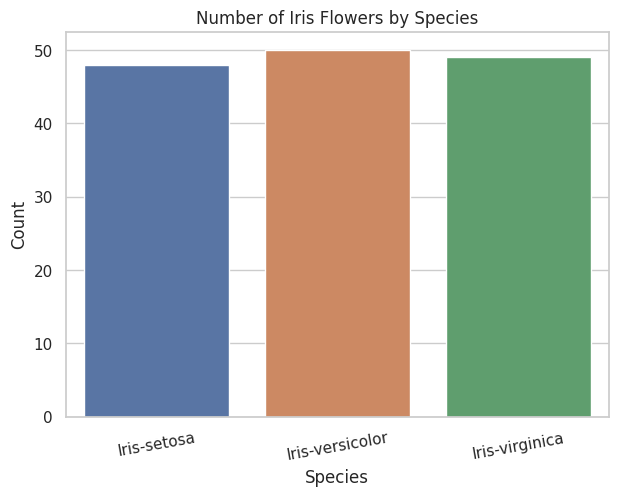

In [7]:
# Visualization 1: Species count
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="species", hue="species", legend=False)
plt.title("Number of Iris Flowers by Species")
plt.xlabel("Species")
plt.ylabel("Count")
plt.xticks(rotation=10)
plt.show()

### Visualization 2 – Feature Histograms
Shows the distribution of each numerical feature.

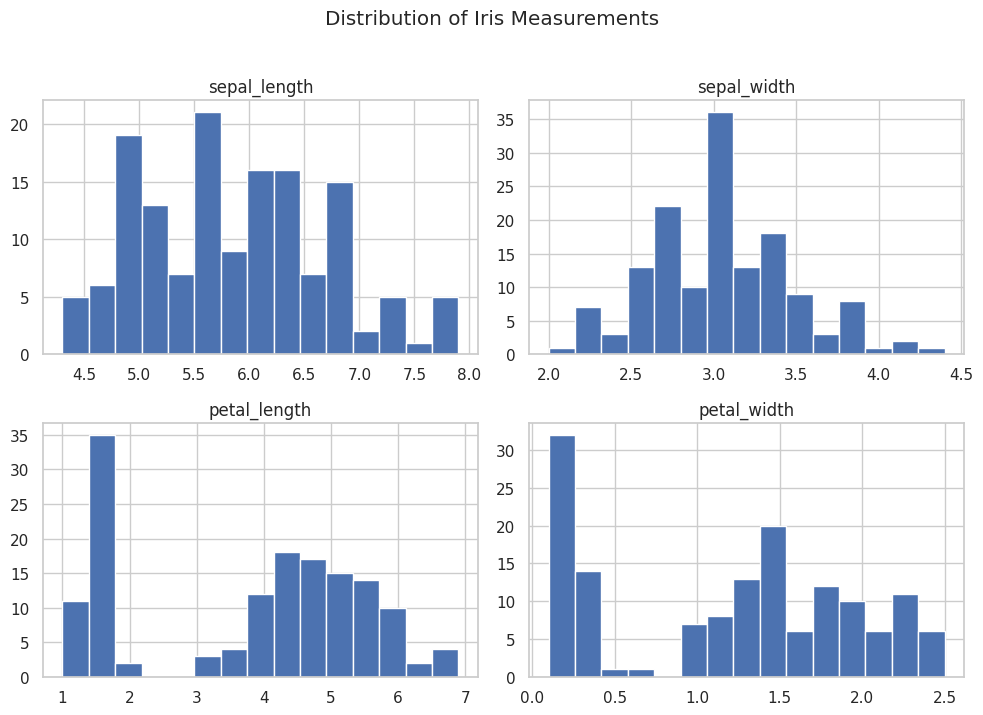

In [8]:
# Visualization 2: Histograms
df[["sepal_length", "sepal_width", "petal_length", "petal_width"]].hist(
    figsize=(10, 7),
    bins=15
)
plt.suptitle("Distribution of Iris Measurements", y=1.02)
plt.tight_layout()
plt.show()

### Visualization 3 – Box Plot
Compares the measurement distributions across species and helps identify differences and possible outliers.

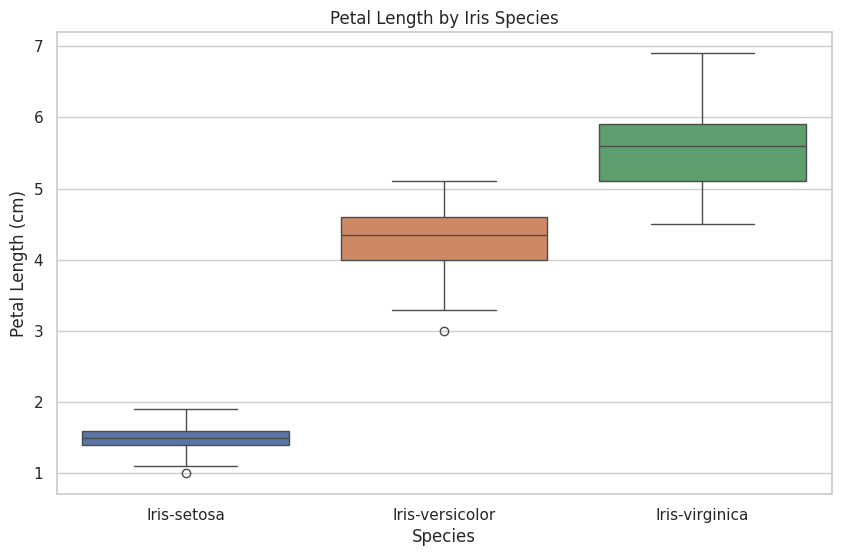

In [9]:
# Visualization 3: Box plot
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x="species",
    y="petal_length",
    hue="species",
    legend=False
)
plt.title("Petal Length by Iris Species")
plt.xlabel("Species")
plt.ylabel("Petal Length (cm)")
plt.show()

### Visualization 4 – Sepal Scatter Plot
Shows the relationship between sepal length and sepal width.

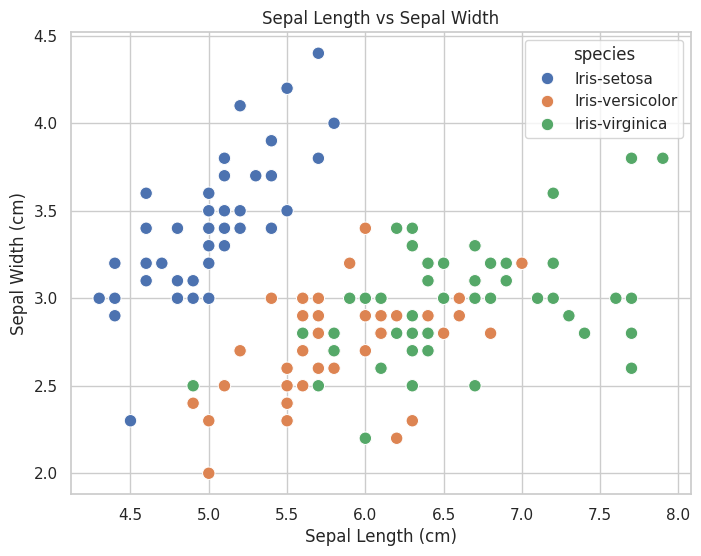

In [10]:
# Visualization 4: Scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="sepal_length",
    y="sepal_width",
    hue="species",
    s=80
)
plt.title("Sepal Length vs Sepal Width")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.show()

### Visualization 5 – Pair Plot
Compares all numerical features and helps identify which measurements separate the species most clearly.

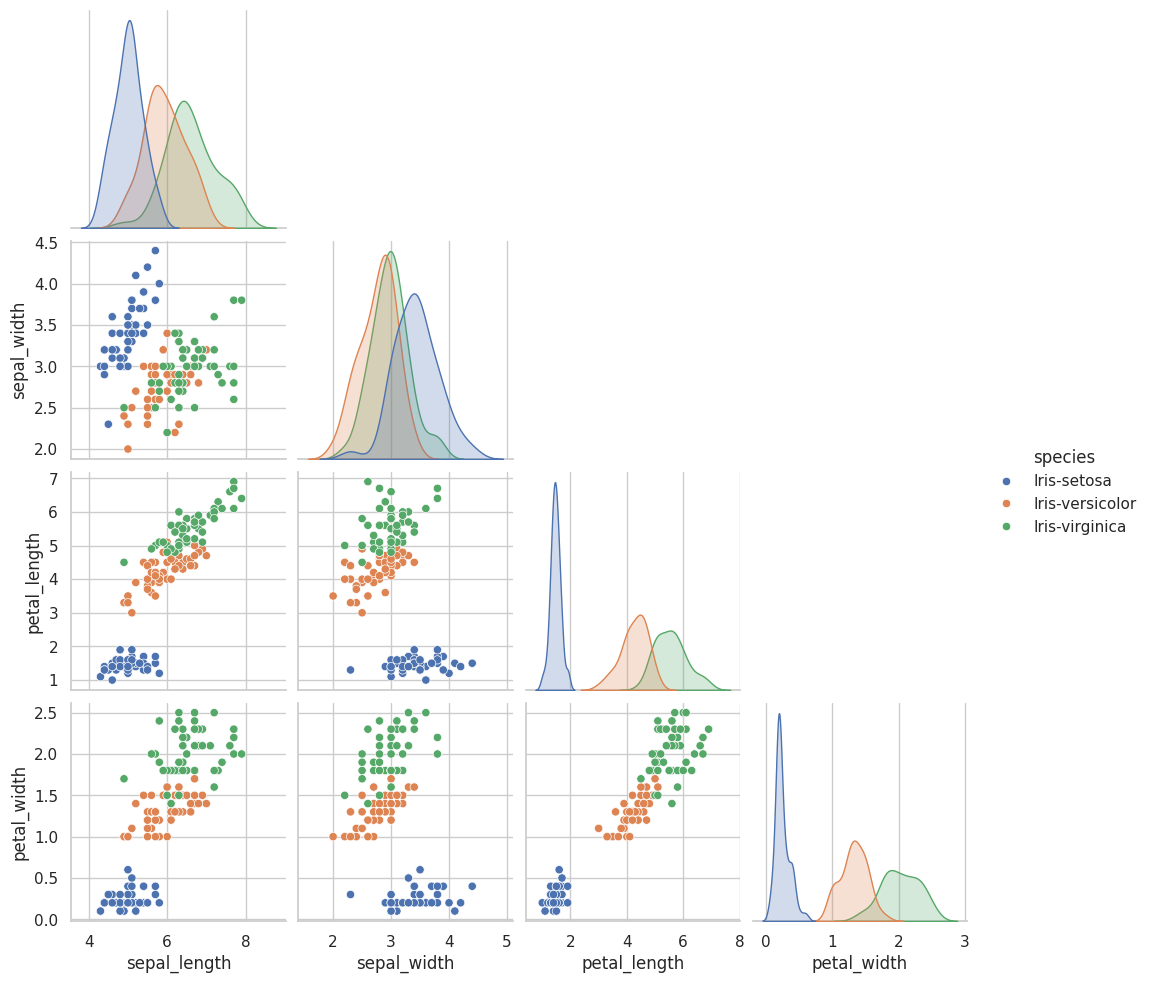

In [11]:
# Visualization 5: Pair plot
sns.pairplot(
    df,
    hue="species",
    corner=True
)
plt.show()

### Visualization 6 – Correlation Heatmap
Shows the correlation between numerical measurements.

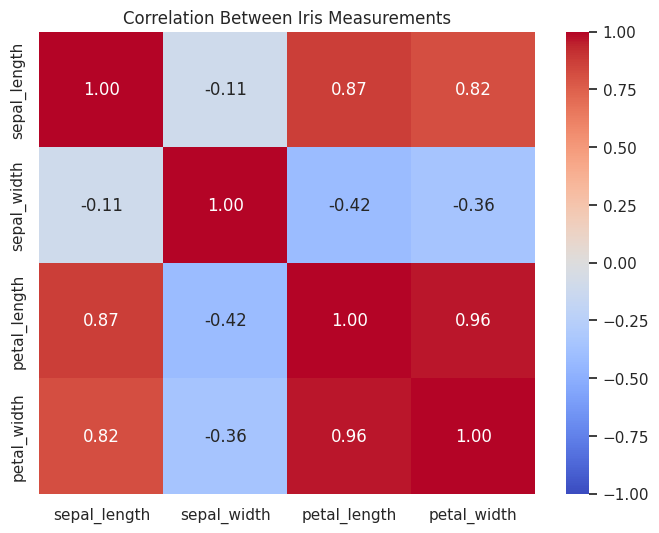

In [12]:
# Visualization 6: Correlation heatmap
plt.figure(figsize=(8, 6))
corr = df[["sepal_length", "sepal_width", "petal_length", "petal_width"]].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Between Iris Measurements")
plt.show()

## 5. Key Insights

Based on the EDA:

1. The dataset contains three iris species with equal class representation.
2. Petal measurements show strong separation between species.
3. Setosa is easier to distinguish from the other two species.
4. Petal length and petal width have a strong positive relationship.
5. Sepal measurements overlap more between species than petal measurements.
6. These patterns make the dataset suitable for a classification model.

In [13]:
# Step 7: Automatically display useful insight values
print("Species counts:")
print(df["species"].value_counts())

print("\nMean measurements:")
display(df.groupby("species").mean(numeric_only=True).round(2))

print("\nCorrelation matrix:")
display(corr.round(2))

Species counts:
species
Iris-versicolor    50
Iris-virginica     49
Iris-setosa        48
Name: count, dtype: int64

Mean measurements:


,sepal_length,sepal_width,petal_length,petal_width
species,,,,
Iris-setosa,5.01,3.43,1.46,0.25
Iris-versicolor,5.94,2.77,4.26,1.33
Iris-virginica,6.60,2.98,5.56,2.03



Correlation matrix:


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.00,-0.11,0.87,0.82
sepal_width,-0.11,1.00,-0.42,-0.36
petal_length,0.87,-0.42,1.00,0.96
petal_width,0.82,-0.36,0.96,1.00


## 6. Machine Learning – K-Nearest Neighbors (KNN)

KNN classifies a new observation by looking at nearby observations in the feature space.

### Steps
1. Select features and target.
2. Split data into training and testing sets.
3. Standardize the features.
4. Train the KNN model.
5. Predict the test data.
6. Calculate accuracy.

In [14]:
# Step 8: Select features and target
X = df[[
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width"
]]

y = df["species"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (147, 4)
Target shape: (147,)


In [15]:
# Step 9: Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 117
Testing rows: 30


In [16]:
# Step 10: Standardize the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [17]:
# Step 11: Train the KNN model
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

print("KNN model trained successfully!")

KNN model trained successfully!


In [18]:
# Step 12: Make predictions
y_pred = knn.predict(X_test_scaled)

print("Predictions:")
print(y_pred)

Predictions:
['Iris-versicolor' 'Iris-versicolor' 'Iris-virginica' 'Iris-setosa'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-setosa'
 'Iris-versicolor' 'Iris-virginica' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-versicolor' 'Iris-virginica' 'Iris-setosa'
 'Iris-versicolor' 'Iris-setosa' 'Iris-virginica' 'Iris-setosa'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor']


## 7. Model Accuracy

In [19]:
# Step 13: Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"KNN Accuracy: {accuracy * 100:.2f}%")

KNN Accuracy: 93.33%


In [20]:
# Step 14: Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.83      1.00      0.91        10
 Iris-virginica       1.00      0.80      0.89        10

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30



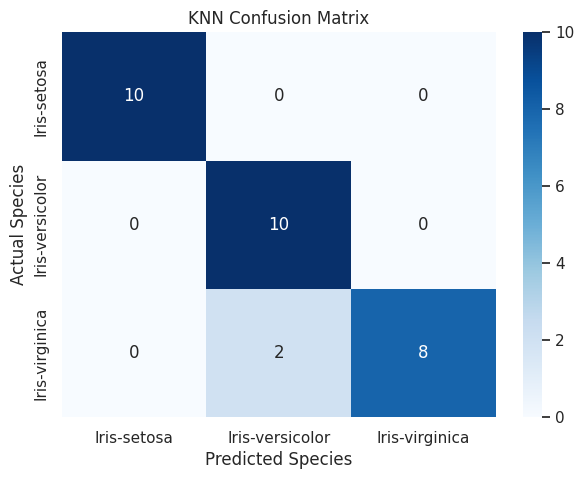

In [21]:
# Step 15: Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=knn.classes_,
    yticklabels=knn.classes_
)

plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")
plt.title("KNN Confusion Matrix")
plt.show()

## 8. Predict a New Iris Flower

The following example predicts the species of a new flower using its four measurements.

In [22]:
# Step 16: Predict a new flower
new_flower = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=X.columns
)

new_flower_scaled = scaler.transform(new_flower)
prediction = knn.predict(new_flower_scaled)

print("New flower measurements:")
display(new_flower)

print("Predicted species:", prediction[0])

New flower measurements:


,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2


Predicted species: Iris-setosa


## 9. Final Conclusion

The Iris dataset was successfully loaded from a public UCI source, checked for missing values and duplicates, explored using descriptive statistics, and analyzed through six visualizations. The EDA showed that petal measurements provide strong separation between the three iris species.

A K-Nearest Neighbors (KNN) classification model was then trained using the four flower measurements. The model was evaluated using accuracy, a classification report, and a confusion matrix. Finally, the trained model was used to predict the species of a new flower.

### Project Outcome
The project demonstrates a complete basic data-science workflow:

**Dataset → Cleaning → EDA → Visualization → Insights → Machine Learning → Evaluation → Prediction**

### Dataset Citation
Fisher, R. (1936). *Iris* [Dataset]. UCI Machine Learning Repository.  
https://doi.org/10.24432/C56C76